In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')
print(df.shape)
df.head()

(9994, 13)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [3]:
print(df.isnull().sum())  # null values check
print(df.dtypes)          # columns ka type check

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64
Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object


In [4]:
df.dropna(inplace=True)          # null rows hatao
df.drop_duplicates(inplace=True) # duplicate rows hatao
print("Clean data rows:", df.shape[0])

Clean data rows: 9977


Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


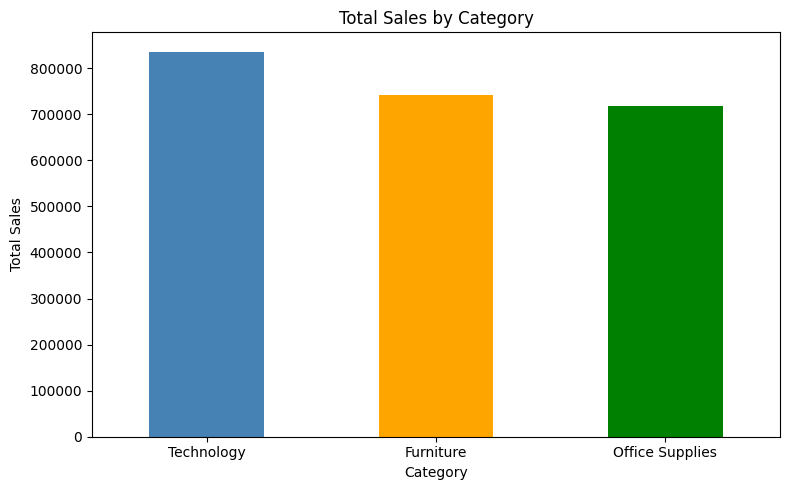

In [5]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color=['steelblue','orange','green'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Region
West       108329.8079
East        91506.3092
South       46749.4303
Central     39655.8752
Name: Profit, dtype: float64


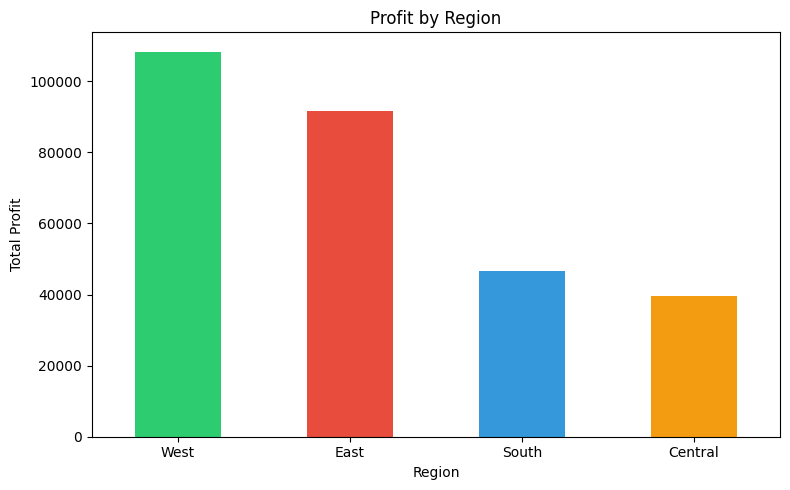

In [6]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(region_profit)

plt.figure(figsize=(8,5))
region_profit.plot(kind='bar', color=['#2ecc71','#e74c3c','#3498db','#f39c12'])
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

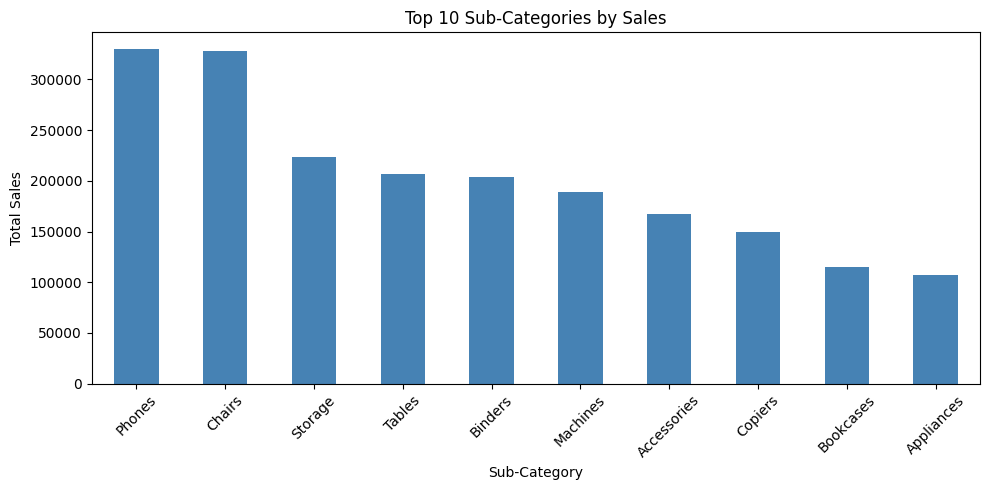

In [9]:
sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sub_sales.plot(kind='bar', color='steelblue')
plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

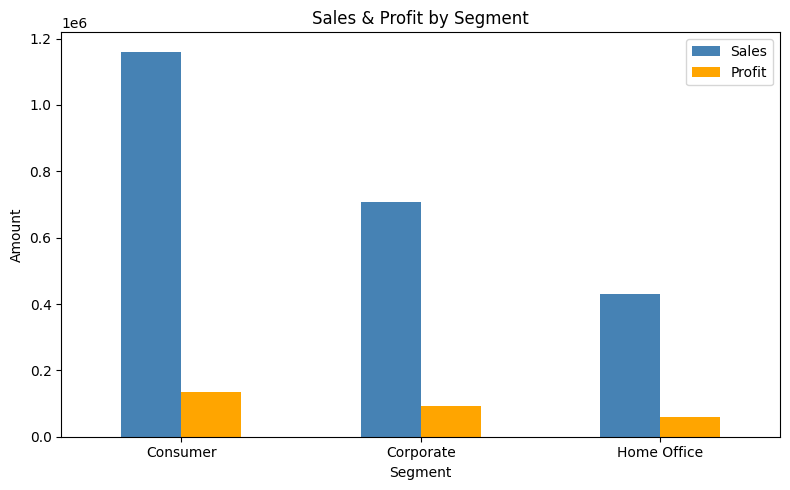

In [12]:
segment_data = df.groupby('Segment')[['Sales','Profit']].sum()

segment_data.plot(kind='bar', figsize=(8,5), color=['steelblue','orange'])
plt.title('Sales & Profit by Segment')
plt.xlabel('Segment')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.legend(['Sales','Profit'])
plt.tight_layout()
plt.show()

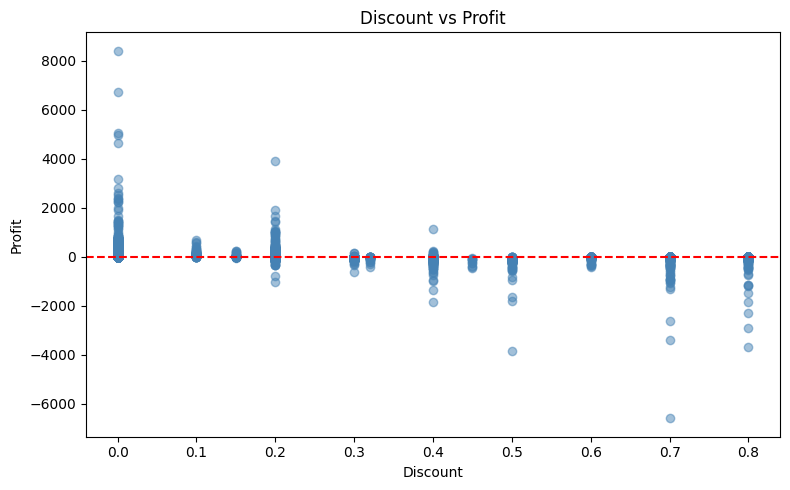

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5, color='steelblue')
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.axhline(y=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

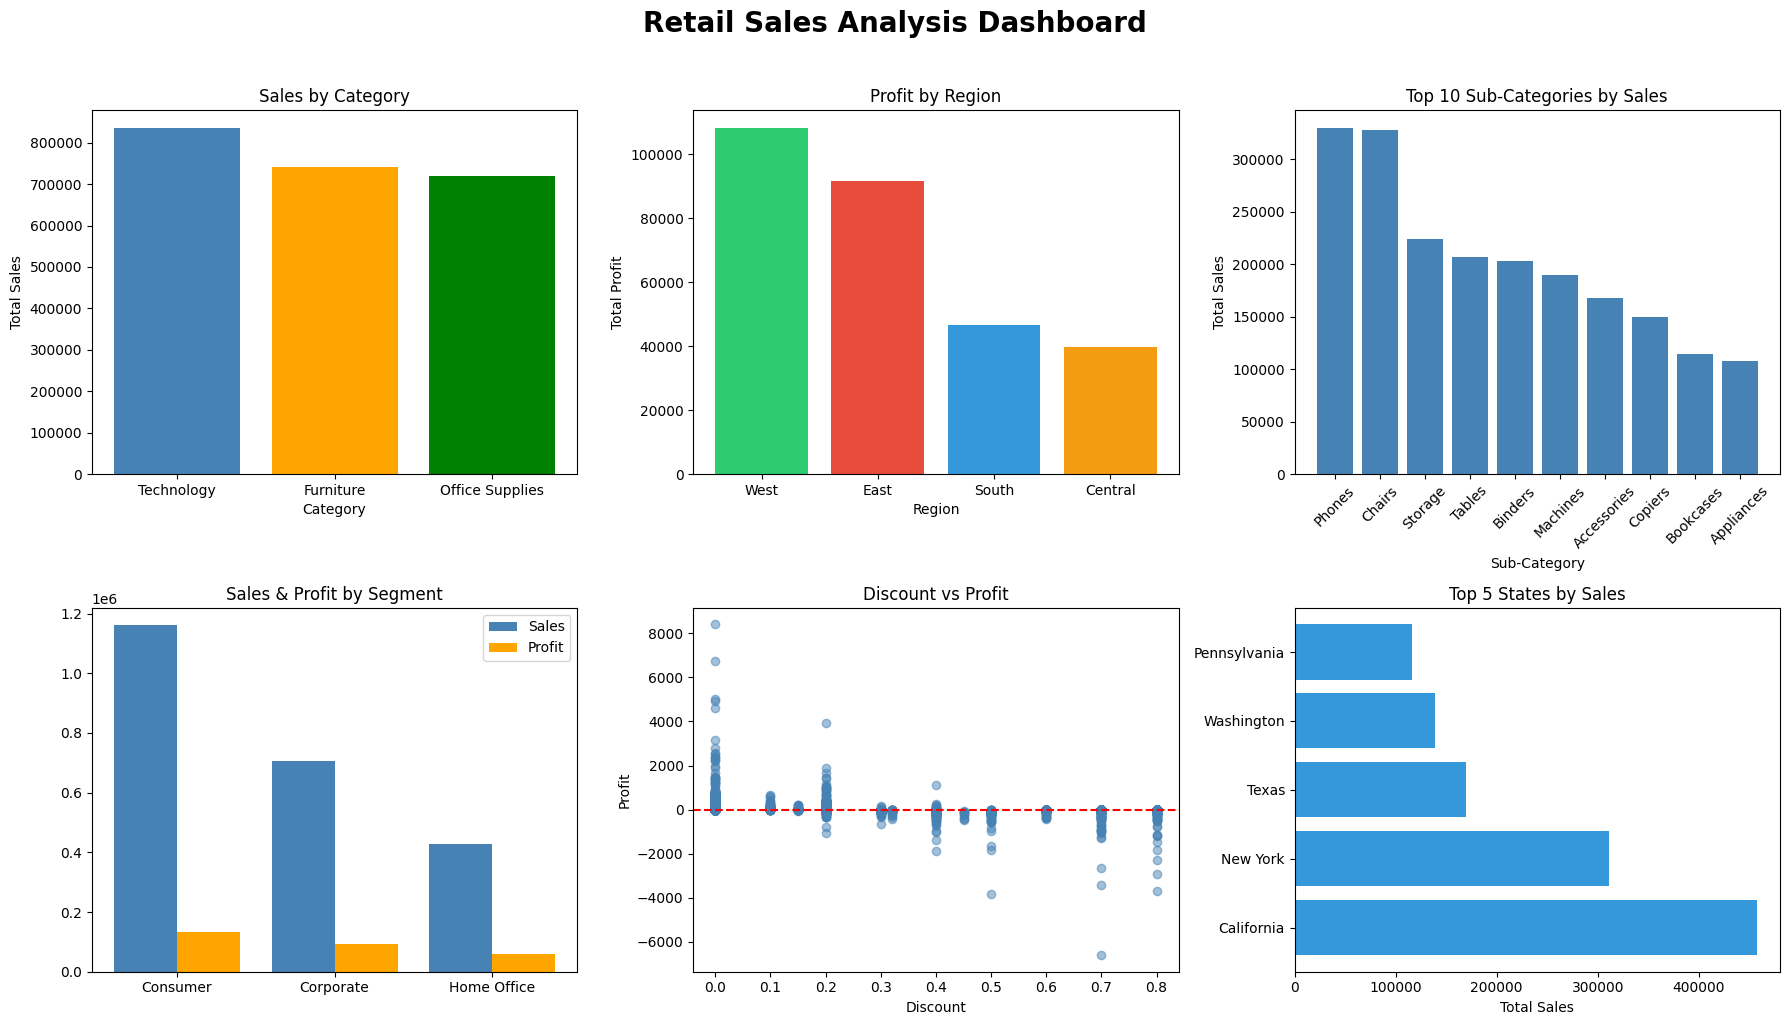

Dashboard saved as retail_dashboard.png!


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Retail Sales Analysis Dashboard', fontsize=20, fontweight='bold', y=1.02)

# Chart 1 - Category wise Sales
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0,0].bar(category_sales.index, category_sales.values, color=['steelblue','orange','green'])
axes[0,0].set_title('Sales by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Total Sales')

# Chart 2 - Region wise Profit
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
axes[0,1].bar(region_profit.index, region_profit.values, color=['#2ecc71','#e74c3c','#3498db','#f39c12'])
axes[0,1].set_title('Profit by Region')
axes[0,1].set_xlabel('Region')
axes[0,1].set_ylabel('Total Profit')

# Chart 3 - Top 10 Sub Categories
sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
axes[0,2].bar(sub_sales.index, sub_sales.values, color='steelblue')
axes[0,2].set_title('Top 10 Sub-Categories by Sales')
axes[0,2].set_xlabel('Sub-Category')
axes[0,2].set_ylabel('Total Sales')
axes[0,2].tick_params(axis='x', rotation=45)

# Chart 4 - Segment wise Sales & Profit
segment_data = df.groupby('Segment')[['Sales','Profit']].sum()
x = range(len(segment_data.index))
axes[1,0].bar([i-0.2 for i in x], segment_data['Sales'], width=0.4, label='Sales', color='steelblue')
axes[1,0].bar([i+0.2 for i in x], segment_data['Profit'], width=0.4, label='Profit', color='orange')
axes[1,0].set_title('Sales & Profit by Segment')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(segment_data.index)
axes[1,0].legend()

# Chart 5 - Discount vs Profit
axes[1,1].scatter(df['Discount'], df['Profit'], alpha=0.5, color='steelblue')
axes[1,1].set_title('Discount vs Profit')
axes[1,1].set_xlabel('Discount')
axes[1,1].set_ylabel('Profit')
axes[1,1].axhline(y=0, color='red', linestyle='--')

# Chart 6 - Top 5 States by Sales
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(5)
axes[1,2].barh(state_sales.index, state_sales.values, color='#3498db')
axes[1,2].set_title('Top 5 States by Sales')
axes[1,2].set_xlabel('Total Sales')

plt.tight_layout()
plt.savefig('retail_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as retail_dashboard.png!")